In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('fake_job_postings.csv')
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
data.drop(columns='job_id',inplace=True)
data.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17879 non-null  object
 6   requirements         15184 non-null  object
 7   benefits             10668 non-null  object
 8   telecommuting        17880 non-null  int64 
 9   has_company_logo     17880 non-null  int64 
 10  has_questions        17880 non-null  int64 
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
telecommuting,17880.0,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0
has_company_logo,17880.0,0.795302,0.403492,0.0,1.0,1.0,1.0,1.0
has_questions,17880.0,0.491723,0.499945,0.0,0.0,0.0,1.0,1.0
fraudulent,17880.0,0.048434,0.214688,0.0,0.0,0.0,0.0,1.0


In [5]:
cat_col=[col for col in  data.columns if data[col].dtypes=='object']
cat_col

['title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function']

In [6]:
for col in cat_col:
    print(f'{col} has {data[col].nunique()} unique values: {data[col].unique()}')

title has 11231 unique values: ['Marketing Intern' 'Customer Service - Cloud Video Production'
 'Commissioning Machinery Assistant (CMA)' ...
 'Senior Financial Analyst (Retail) ' 'Account Director - Distribution '
 'Project Cost Control Staff Engineer - Cost Control Exp - TX']
location has 3105 unique values: ['US, NY, New York' 'NZ, , Auckland' 'US, IA, Wever' ...
 'US, CA, los Angeles' 'CA, , Ottawa' 'GB, WSX, Chichester']
department has 1337 unique values: ['Marketing' 'Success' nan ... 'Admin - Clerical' 'Administrative Dept'
 'Hospitality']
salary_range has 874 unique values: [nan '20000-28000' '100000-120000' '120000-150000' '50000-65000'
 '40000-50000' '60-80' '65000-70000' '75-115' '75000-110000' '17000-20000'
 '16000-28000' '95000-115000' '15000-18000' '50000-70000' '45000-60000'
 '30000-40000' '70000-90000' '10000-14000' '50-110' '28000-45000'
 '0-34300' '35000-40000' '9-Dec' '44000-57000' '18500-28000' '55000-75000'
 '30000-35000' '0-0' '20000-40000' '360000-600000' '50000-

In [7]:
num_col=[col for col in data.columns if data[col].dtype !='object']
num_col

['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']

In [8]:
data.isna().sum()

,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0
has_company_logo,0


In [9]:
data.isna().sum()/len(data)

,0
title,0.000000
location,0.019351
department,0.645805
salary_range,0.839597
company_profile,0.185011
description,0.000056
requirements,0.150783
benefits,0.403356
telecommuting,0.000000
has_company_logo,0.000000


In [10]:
data[data['salary_range'].notna()].loc[:,'salary_range'].value_counts()

,count
salary_range,
0-0,142
40000-50000,66
30000-40000,55
45000-67000,37
25000-30000,37
...,...
55000-69000,1
360000-500000,1
50000-95000,1


In [11]:
data['salary_missed']=np.where(data['salary_range'].isna(),1,0)
data.drop(columns='salary_range',inplace=True)
data.head()

,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,salary_missed
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,1
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,1
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,1
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,1
4,Bill Review Manager,"US, FL, Fort Worth",NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1


In [12]:
data['location'].value_counts(sort=True).head(50)

,count
location,
"GB, LND, London",718
"US, NY, New York",658
"US, CA, San Francisco",472
"GR, I, Athens",464
"US, ,",339
"US, TX, Houston",269
"US, IL, Chicago",255
"US, DC, Washington",251
"DE, BE, Berlin",221


In [13]:
data['country']=data['location'].str.extract(r'([A-Z]+)')
data['country']

,country
0,US
1,NZ
2,US
3,US
4,US
...,...
17875,CA
17876,US
17877,US
17878,NG


In [14]:
data['state']=data['location'].str.extract(r',\s*([A-Z]+)')
data['city'] = data['location'].str.extract(r',\s*([a-zA-Z\s]+)$')
data.drop(columns='location',inplace=True)

In [15]:
data.head(10)

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,salary_missed,country,state,city
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,1,US,NY,New York
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,1,NZ,A,Auckland
2,Commissioning Machinery Assistant (CMA),NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,1,US,IA,Wever
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,1,US,DC,Washington
4,Bill Review Manager,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1,US,FL,Fort Worth
5,Accounting Clerk,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0,1,US,MD,
6,Head of Content (m/f),ANDROIDPIT,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0,0,DE,BE,Berlin
7,Lead Guest Service Specialist,NaN,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,NaN,NaN,NaN,NaN,NaN,0,1,US,CA,San Francisco
8,HP BSM SME,NaN,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,NaN,0,1,1,Full-time,Associate,NaN,Information Technology and Services,NaN,0,1,US,FL,Pensacola
9,Customer Service Associate - Part Time,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Financial Services,Customer Service,0,1,US,AZ,Phoenix


In [16]:
data['city']=data['city'].replace(' ',np.nan)
data['city'].value_counts(sort=True).head(50)

,count
city,
London,1069
New York,669
Athens,553
San Francisco,478
Houston,272
Berlin,262
Chicago,257
Washington,255
Auckland,227


In [17]:
data['state'].value_counts(sort=True).head(50)

,count
state,
CA,2051
NY,1259
LND,992
TX,975
I,704
IL,424
FL,415
OH,372
VA,332


In [18]:
data['country'].value_counts(sort=True).head(50)

,count
country,
US,10656
GB,2384
GR,940
CA,457
DE,383
NZ,333
IN,276
AU,214
PH,132


In [19]:
data['country']=data['country'].fillna('unknown')
data['state']=data['state'].fillna('unknown')
data['city']=data['city'].fillna('unknown')

In [20]:
data['department_missing']=np.where(data['department'].isna(),1,0)
data['department']=data['department'].fillna('unknown')

In [21]:
data['company_profile_missed']=np.where(data['company_profile'].isna(),1,0)
data['company_profile']=data['company_profile'].fillna('Unknown')

In [22]:
data['requirements_missed']=np.where(data['requirements'].isna(),1,0)
data['requirements']=data['requirements'].fillna('Unknown')

In [23]:
data['benefits_missed']=np.where(data['benefits'].isna(),1,0)
data['benefits']=data['requirements'].fillna('Unknown')

In [24]:
data['employment_type']=data['employment_type'].replace(np.nan,'Other')


In [25]:
data['required_experience']=data['required_experience'].replace(np.nan,'Not Applicable')

In [26]:
data['required_education']=data['required_education'].replace(np.nan,'Unspecified')

In [27]:
data['industry_missid']=np.where(data['industry'].isna(),1,0)
data['industry']=data['industry'].fillna('Unknown')


In [28]:
data['function']=data['function'].replace(np.nan,'Other')


In [29]:
data.isna().sum()

,0
title,0
department,0
company_profile,0
description,1
requirements,0
benefits,0
telecommuting,0
has_company_logo,0
has_questions,0
employment_type,0


In [30]:
data.dropna(inplace=True)

In [31]:
data.isna().sum()

,0
title,0
department,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0
has_questions,0
employment_type,0


In [32]:
data.duplicated().sum()

np.int64(302)

In [33]:
data[data.duplicated()]

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,...,fraudulent,salary_missed,country,state,city,department_missing,company_profile_missed,requirements_missed,benefits_missed,industry_missid
146,Customer Service Associate,unknown,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,QualificationsMinimum of 6 months customer ser...,QualificationsMinimum of 6 months customer ser...,0,1,0,Full-time,...,0,1,US,TX,Dallas,1,0,0,1,0
280,English Teacher Abroad,unknown,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,University degree required. TEFL / TESOL / CEL...,0,1,1,Contract,...,0,1,US,MO,unknown,1,0,0,0,0
402,Inside Sales Professional-Omaha,unknown,"ABC Supply Co., Inc. is the nation’s largest w...","As a Sales Representative, you will provide as...","As a Sales Representative, you must have the a...","As a Sales Representative, you must have the a...",0,1,0,Full-time,...,0,1,US,NE,Omaha,1,0,0,0,0
495,Customer Service Associate - Part Time,unknown,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,Minimum Requirements:Minimum of 6 months custo...,0,1,0,Full-time,...,0,1,US,IL,Warrenville,1,0,0,1,0
1019,Texas Captioning Assistant,CSD Relay,"Why CSD?CSD is not only a great place to work,...",Captioning Assistants provide quick and accura...,A minimum of a High School Diploma or equivale...,A minimum of a High School Diploma or equivale...,0,1,1,Other,...,0,1,US,TX,Lubbock,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17591,Home Based Payroll Typist/Data Entry Clerks Po...,Clerical,Unknown,We have several openings available in this are...,"Basic computer and typing skills, ability to s...","Basic computer and typing skills, ability to s...",0,0,0,Other,...,1,1,US,MT,Absarokee,0,1,0,0,1
17612,Urgent Jobs (Part Time Workers Needed),unknown,Unknown,Urgent Jobs (Part Time Workers Needed)You can ...,No any experience required.,No any experience required.,0,0,0,Part-time,...,1,1,AU,NSW,Sydney,1,1,0,1,1
17620,Data Entry Admin/Clerical Positions - Work Fro...,unknown,Unknown,ACCEPTING ONLINE APPLICATIONS ONLYClick Here T...,Unknown,Unknown,0,0,0,Other,...,1,1,US,NE,Omaha,1,1,1,1,1
17742,Data Entry Admin/Clerical Positions - Work Fro...,unknown,Unknown,ACCEPTING ONLINE APPLICATIONS ONLYClick Here T...,Unknown,Unknown,0,0,0,Other,...,1,1,US,NE,Omaha,1,1,1,1,1


In [34]:
data.drop_duplicates(inplace=True)
data.reset_index(inplace=True,drop=True)
data.duplicated().sum()

np.int64(0)

In [35]:
data.head()

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,...,fraudulent,salary_missed,country,state,city,department_missing,company_profile_missed,requirements_missed,benefits_missed,industry_missid
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Experience with content management systems a m...,0,1,0,Other,...,0,1,US,NY,New York,0,0,0,1,1
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What we expect from you:Your key responsibilit...,0,1,0,Full-time,...,0,1,NZ,A,Auckland,0,0,0,0,0
2,Commissioning Machinery Assistant (CMA),unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Implement pre-commissioning and commissioning ...,0,1,0,Other,...,0,1,US,IA,Wever,1,0,0,1,1
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...","EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,Full-time,...,0,1,US,DC,Washington,0,0,0,0,0
4,Bill Review Manager,unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,Full-time,...,0,1,US,FL,Fort Worth,1,0,0,0,0


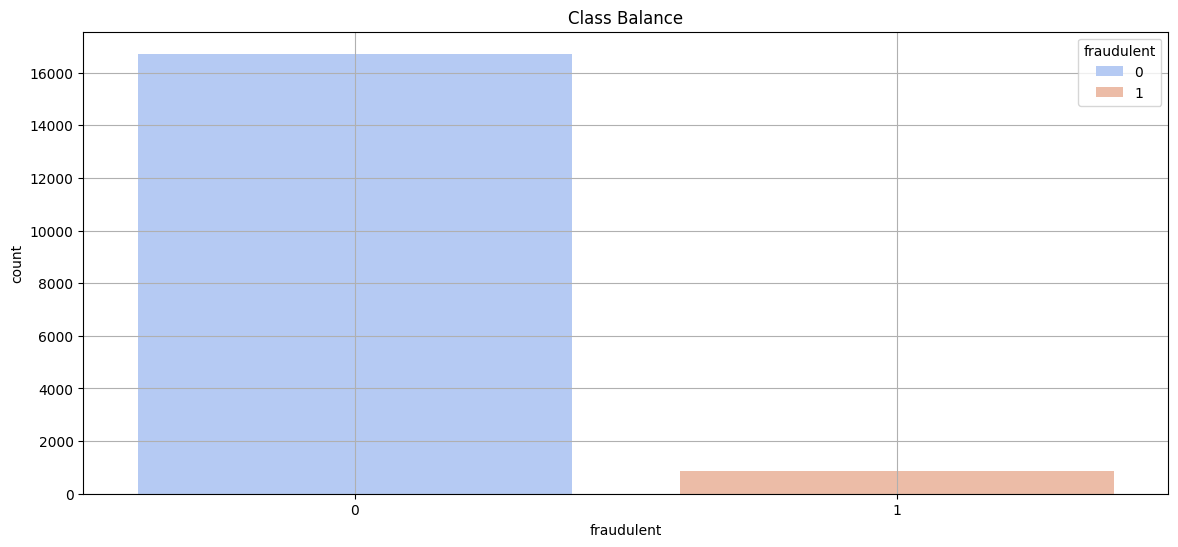

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
sns.countplot(x='fraudulent',data=data,palette='coolwarm',hue='fraudulent')
plt.title('Class Balance')
plt.grid()
plt.show()

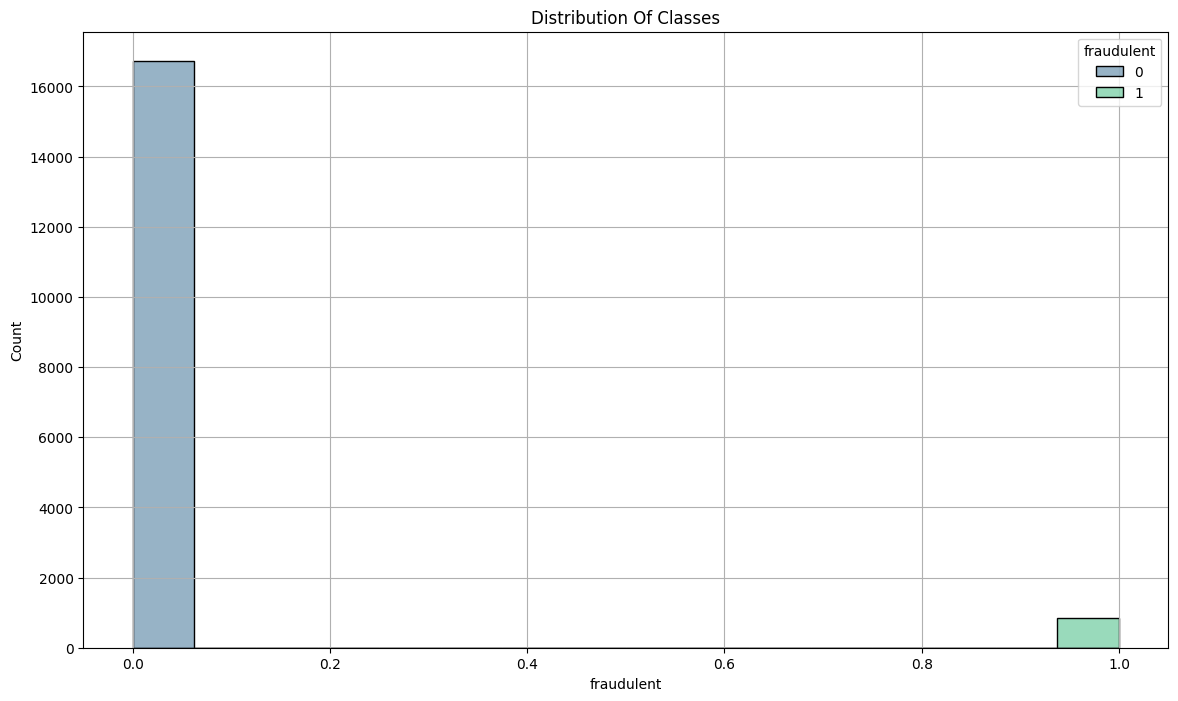

In [37]:
plt.figure(figsize=(14,8))
sns.histplot(x='fraudulent',data=data,palette='viridis',hue='fraudulent')
plt.title('Distribution Of Classes')
plt.grid()
plt.show()

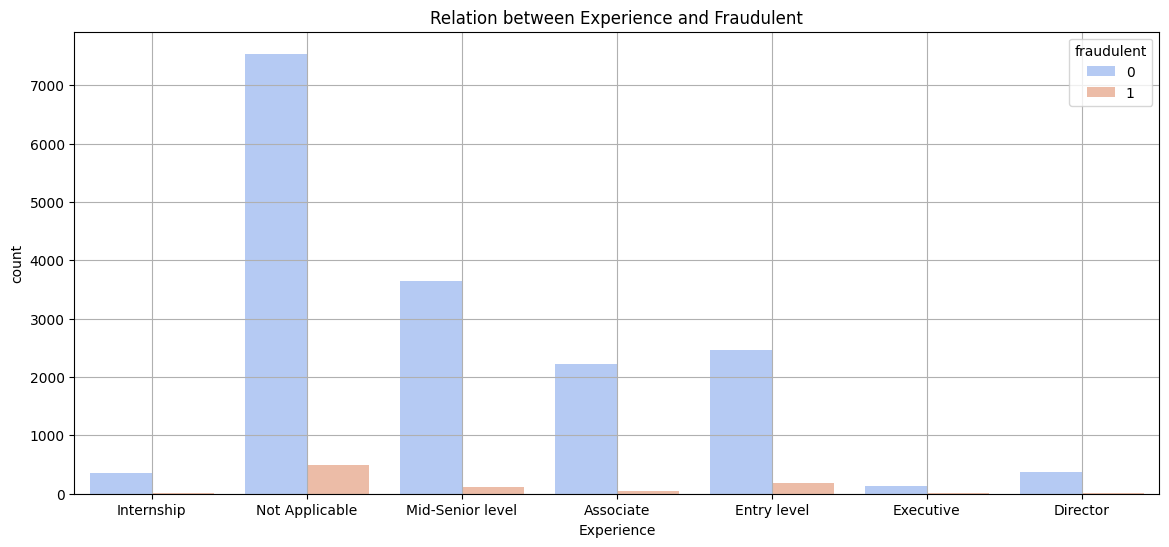

In [38]:
plt.figure(figsize=(14,6))
sns.countplot(x='required_experience',data=data,palette='coolwarm',hue='fraudulent')
plt.title('Relation between Experience and Fraudulent')
plt.xlabel('Experience')
plt.grid()
plt.show()

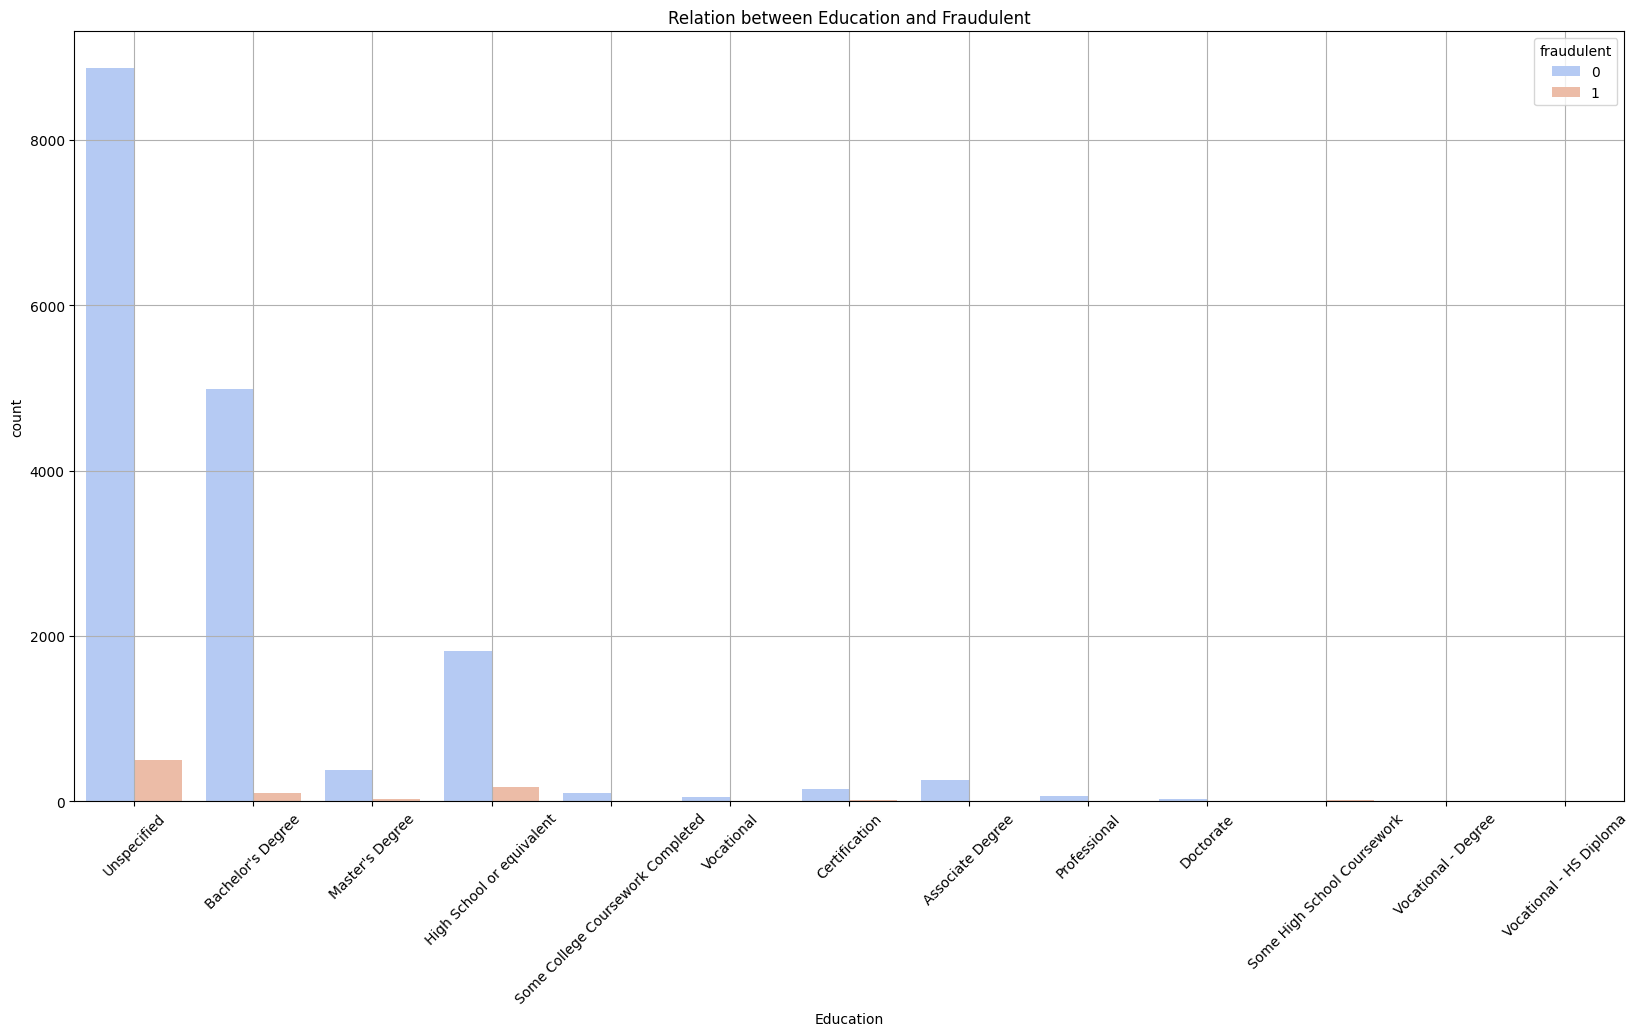

In [40]:
plt.figure(figsize=(20,10))
sns.countplot(x='required_education',data=data,palette='coolwarm',hue='fraudulent')
plt.title('Relation between Education and Fraudulent')
plt.xlabel('Education')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [41]:
employment_df=data.groupby('employment_type')['fraudulent'].mean()
employment_df

,fraudulent
employment_type,
Contract,0.028458
Full-time,0.042693
Other,0.068219
Part-time,0.094560
Temporary,0.008439


In [42]:
import plotly.express as px
fig = px.bar(
    x=employment_df.index,
    y=employment_df.values,
    labels={'x': 'Employment Type', 'y': 'Frequency'}
)

fig.update_traces(
    text=employment_df.values,
    textposition='outside',
    marker_color='royalblue'
)

fig.update_layout(
    title={'text': "Employment Type Fraudulent Frequency", 'x': 0.5},
    xaxis_title="Employment Type",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

In [43]:
function_df=data.groupby('function')['fraudulent'].mean()
function_df

,fraudulent
function,
Accounting/Auditing,0.138095
Administrative,0.194127
Advertising,0.055556
Art/Creative,0.007634
Business Analyst,0.012048
Business Development,0.057522
Consulting,0.028986
Customer Service,0.056924
Data Analyst,0.048780


In [44]:
fig=px.bar(x=function_df.index,y=function_df.values,
           labels={'x':'funcatio','y':'fraudulent'})
fig.update_traces(
    text=employment_df.values,
    textposition='outside',
    marker_color='royalblue'
)

fig.update_layout(
    title={'text': "function Type Fraudulent Frequency", 'x': 0.5},
    xaxis_title="function",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

Text(0.5, 1.0, "person's r")

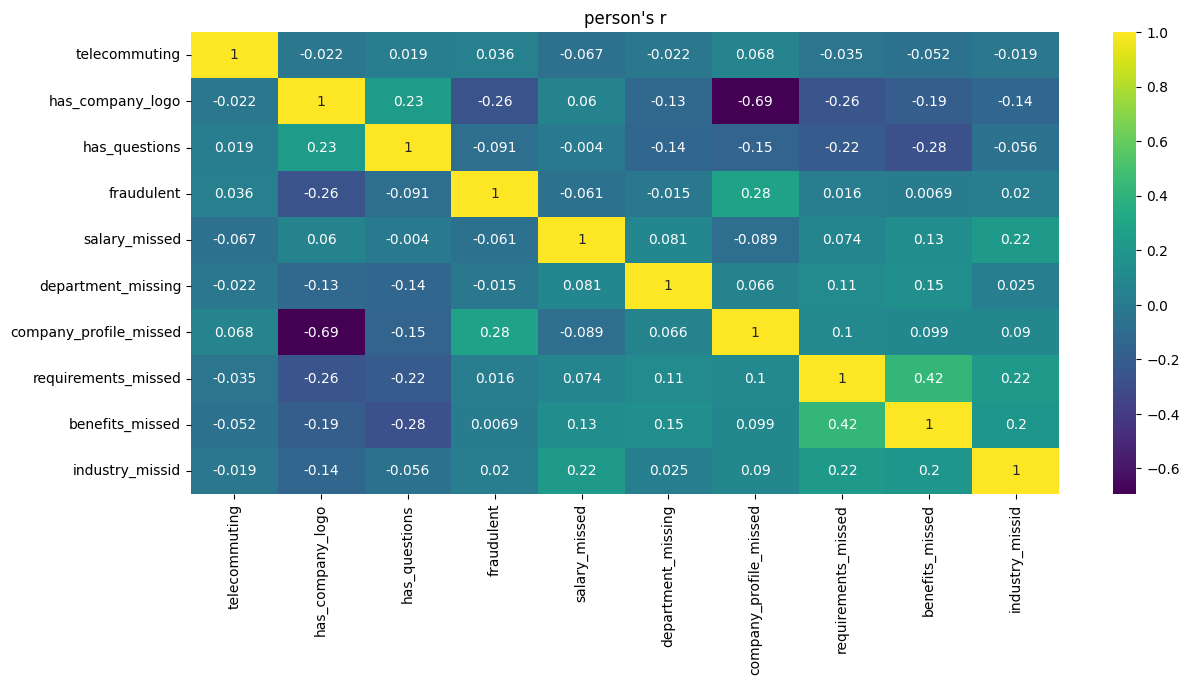

In [45]:
plt.figure(figsize=(14,6))
corr=data.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='viridis')
plt.title('person\'s r')

In [46]:
q1 = data.select_dtypes(exclude='object').quantile(0.25)
q3 = data.select_dtypes(exclude='object').quantile(0.75)
iqr = q3 - q1
lb = q1 - 1.5*iqr
ub = q3 + 1.5*iqr



mask=(data.select_dtypes(exclude='object') < lb) | (data.select_dtypes(exclude='object')>ub)
outlier=data[mask.any(axis=1)]
outlier

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,...,fraudulent,salary_missed,country,state,city,department_missing,company_profile_missed,requirements_missed,benefits_missed,industry_missid
5,Accounting Clerk,unknown,Unknown,Job OverviewApex is an environmental consultin...,Unknown,Unknown,0,0,0,Other,...,0,1,US,MD,unknown,1,1,1,1,1
6,Head of Content (m/f),ANDROIDPIT,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Know-How: ...,0,1,1,Full-time,...,0,0,DE,BE,Berlin,0,0,0,0,0
10,ASP.net Developer Job opportunity at United St...,unknown,Unknown,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,0,0,0,Full-time,...,0,0,US,NJ,Jersey City,1,1,0,0,0
15,VP of Sales - Vault Dragon,Sales,Jungle Ventures is the leading Singapore based...,About Vault Dragon Vault Dragon is Dropbox for...,Key Superpowers3-5 years of high-pressure sale...,Key Superpowers3-5 years of high-pressure sale...,0,1,1,Full-time,...,0,0,SG,S,Singapore,0,0,0,0,0
18,Visual Designer,unknown,Kettle is an independent digital agency based ...,Kettle is hiring a Visual Designer!Job Locatio...,Unknown,Unknown,0,1,0,Other,...,0,1,US,NY,New York,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17566,Sr Technical Lead LIMS,unknown,Unknown,Job Title: Sr Technical LeadSalary: OpenDurat...,Responsibilities: He should be extensive knowl...,Responsibilities: He should be extensive knowl...,0,0,0,Full-time,...,0,1,US,DE,Wilmington,1,1,0,1,0
17570,Recruiting Coordinator,unknown,Unknown,RESPONSIBILITIES:Will facilitate the recruitin...,REQUIRED SKILLS:Associates Degree or a combina...,REQUIRED SKILLS:Associates Degree or a combina...,0,1,0,Contract,...,0,1,US,NC,Charlotte,1,1,0,1,0
17571,JavaScript Developer,unknown,Unknown,"Sr, JavaScript Developer Experience : 4-10 yea...",Unknown,Unknown,0,0,0,Full-time,...,0,0,US,unknown,unknown,1,1,1,1,0
17574,Project Cost Control Staff Engineer - Cost Con...,unknown,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,At least 12 years professional experience.Abil...,0,0,0,Full-time,...,0,1,US,TX,Houston,1,0,0,1,1


In [47]:
outlier['fraudulent'].value_counts()

,count
fraudulent,
0,7137
1,854


In [48]:
required_experience_dic={
    'Not Applicable':-1,
    'Internship':0,
    'Entry level':1,
    'Associate':2,
    'Mid-Senior level':3,
    'Director':4,
    'Executive':5,
}
data['required_experience']=data['required_experience'].map(required_experience_dic)

In [49]:
data['required_experience'].head()

,required_experience
0,0
1,-1
2,-1
3,3
4,3


In [50]:
required_education_dic={
    'Unspecified':-1,
    'Some High School Coursework':0,
    'High School or equivalent':1,
    'Vocational':2,
    'Vocational - HS Diploma':3,
    'Vocational - Degree':4,
    'Certification':5,
    'Some College Coursework Completed':6,
    'Associate Degree':7,
    "Bachelor's Degree":8,
    'Professional':9,
    "Master's Degree":10,
    'Doctorate':11
}
data['required_education']=data['required_education'].map(required_education_dic)

In [51]:
data['required_education'].head()

,required_education
0,-1
1,-1
2,-1
3,8
4,8


In [52]:
data.head()

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,...,fraudulent,salary_missed,country,state,city,department_missing,company_profile_missed,requirements_missed,benefits_missed,industry_missid
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Experience with content management systems a m...,0,1,0,Other,...,0,1,US,NY,New York,0,0,0,1,1
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What we expect from you:Your key responsibilit...,0,1,0,Full-time,...,0,1,NZ,A,Auckland,0,0,0,0,0
2,Commissioning Machinery Assistant (CMA),unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Implement pre-commissioning and commissioning ...,0,1,0,Other,...,0,1,US,IA,Wever,1,0,0,1,1
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...","EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,Full-time,...,0,1,US,DC,Washington,0,0,0,0,0
4,Bill Review Manager,unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,Full-time,...,0,1,US,FL,Fort Worth,1,0,0,0,0


In [53]:
data['department'].nunique()

1338

In [54]:
data['department'].value_counts(normalize=True)

,proportion
department,
unknown,0.643625
Sales,0.030665
Engineering,0.027479
Marketing,0.022529
Operations,0.015133
...,...
Front Desk Administration,0.000057
Technical Service,0.000057
Wright Satellite Connections,0.000057


In [55]:
freq=data['department'].value_counts()
top=freq[freq>10].index
len(top)

72

In [56]:
data['department']=np.where(data['department'].isin(top),data['department'],'other')
data['department'].unique()

array(['Marketing', 'other', 'unknown', 'Sales', 'HR', 'Engagement',
       'All', 'Design', 'Production', 'Engineering', 'IT',
       'Business Development', 'Human Resources', 'Oil & Energy',
       'Client Services', 'Operations', 'tech', 'R&D', 'Development',
       'Technology', 'Tech', 'Management', 'Squiz ', 'Finance', 'Retail',
       'Product', 'Account Management', 'Sales and Marketing',
       'Accounting', 'sales', 'Maintenance', 'Performance Marketing',
       'Commercial', 'CSD Relay', 'Editorial', 'Creative', 'Department',
       'Permanent', 'Digital', 'Admin', 'Information Technology',
       'Engineering ', 'Customer Support', 'Administrative', 'Technical',
       'Sales ', 'Content', 'Customer Service', 'International Growth',
       'Support', 'Education', 'CS', 'Project Management', 'Product Team',
       'Creative Services', 'Legal', 'Technical Support', 'QA',
       'Administration', 'Product Innovation', 'Didactics', 'Warehouse',
       'Marketing ', 'Product De

In [57]:
data['department']=data['department'].str.lower().str.strip()
data['department'].unique()

array(['marketing', 'other', 'unknown', 'sales', 'hr', 'engagement',
       'all', 'design', 'production', 'engineering', 'it',
       'business development', 'human resources', 'oil & energy',
       'client services', 'operations', 'tech', 'r&d', 'development',
       'technology', 'management', 'squiz', 'finance', 'retail',
       'product', 'account management', 'sales and marketing',
       'accounting', 'maintenance', 'performance marketing', 'commercial',
       'csd relay', 'editorial', 'creative', 'department', 'permanent',
       'digital', 'admin', 'information technology', 'customer support',
       'administrative', 'technical', 'content', 'customer service',
       'international growth', 'support', 'education', 'cs',
       'project management', 'product team', 'creative services', 'legal',
       'technical support', 'qa', 'administration', 'product innovation',
       'didactics', 'warehouse', 'product development', 'clerical',
       'software development', 'business'

In [58]:
data['department']=data['department'].replace(r'[^a-zA-Z\s]','',regex=True)
data['department'].unique()


array(['marketing', 'other', 'unknown', 'sales', 'hr', 'engagement',
       'all', 'design', 'production', 'engineering', 'it',
       'business development', 'human resources', 'oil  energy',
       'client services', 'operations', 'tech', 'rd', 'development',
       'technology', 'management', 'squiz', 'finance', 'retail',
       'product', 'account management', 'sales and marketing',
       'accounting', 'maintenance', 'performance marketing', 'commercial',
       'csd relay', 'editorial', 'creative', 'department', 'permanent',
       'digital', 'admin', 'information technology', 'customer support',
       'administrative', 'technical', 'content', 'customer service',
       'international growth', 'support', 'education', 'cs',
       'project management', 'product team', 'creative services', 'legal',
       'technical support', 'qa', 'administration', 'product innovation',
       'didactics', 'warehouse', 'product development', 'clerical',
       'software development', 'business', 

In [59]:
dep_dic={
    'hr':'human resources',
    'it':'information technology',
    'admin':'administrative'
}
data['department']=data['department'].replace(dep_dic)
data['department'].unique()

array(['marketing', 'other', 'unknown', 'sales', 'human resources',
       'engagement', 'all', 'design', 'production', 'engineering',
       'information technology', 'business development', 'oil  energy',
       'client services', 'operations', 'tech', 'rd', 'development',
       'technology', 'management', 'squiz', 'finance', 'retail',
       'product', 'account management', 'sales and marketing',
       'accounting', 'maintenance', 'performance marketing', 'commercial',
       'csd relay', 'editorial', 'creative', 'department', 'permanent',
       'digital', 'administrative', 'customer support', 'technical',
       'content', 'customer service', 'international growth', 'support',
       'education', 'cs', 'project management', 'product team',
       'creative services', 'legal', 'technical support', 'qa',
       'administration', 'product innovation', 'didactics', 'warehouse',
       'product development', 'clerical', 'software development',
       'business', 'art studio', 'custom

In [60]:
data['function'].unique()

array(['Marketing', 'Customer Service', 'Other', 'Sales',
       'Health Care Provider', 'Management', 'Information Technology',
       'Engineering', 'Administrative', 'Design', 'Production',
       'Education', 'Supply Chain', 'Business Development',
       'Product Management', 'Financial Analyst', 'Consulting',
       'Human Resources', 'Project Management', 'Manufacturing',
       'Public Relations', 'Strategy/Planning', 'Advertising', 'Finance',
       'General Business', 'Research', 'Accounting/Auditing',
       'Art/Creative', 'Quality Assurance', 'Data Analyst',
       'Business Analyst', 'Writing/Editing', 'Distribution', 'Science',
       'Training', 'Purchasing', 'Legal'], dtype=object)

In [61]:
data['function']=data['function'].str.lower().str.strip()
data['function']=data['function'].replace(r'[^a-zA-Z\s]','',regex=True)
data['function'].unique()

array(['marketing', 'customer service', 'other', 'sales',
       'health care provider', 'management', 'information technology',
       'engineering', 'administrative', 'design', 'production',
       'education', 'supply chain', 'business development',
       'product management', 'financial analyst', 'consulting',
       'human resources', 'project management', 'manufacturing',
       'public relations', 'strategyplanning', 'advertising', 'finance',
       'general business', 'research', 'accountingauditing',
       'artcreative', 'quality assurance', 'data analyst',
       'business analyst', 'writingediting', 'distribution', 'science',
       'training', 'purchasing', 'legal'], dtype=object)

In [62]:
data['function'].value_counts().tail(10)

,count
function,
general business,68
research,50
strategyplanning,46
legal,43
training,37
supply chain,36
financial analyst,29
distribution,24
purchasing,15


In [63]:
data['industry'].unique()

array(['Unknown', 'Marketing and Advertising', 'Computer Software',
       'Hospital & Health Care', 'Online Media',
       'Information Technology and Services', 'Financial Services',
       'Management Consulting', 'Events Services', 'Internet',
       'Facilities Services', 'Consumer Electronics',
       'Telecommunications', 'Consumer Services', 'Construction',
       'Oil & Energy', 'Education Management', 'Building Materials',
       'Banking', 'Food & Beverages', 'Food Production',
       'Health, Wellness and Fitness', 'Insurance', 'E-Learning',
       'Cosmetics', 'Staffing and Recruiting',
       'Venture Capital & Private Equity', 'Leisure, Travel & Tourism',
       'Human Resources', 'Pharmaceuticals', 'Farming', 'Legal Services',
       'Luxury Goods & Jewelry', 'Machinery', 'Real Estate',
       'Mechanical or Industrial Engineering',
       'Public Relations and Communications', 'Consumer Goods',
       'Medical Practice', 'Electrical/Electronic Manufacturing',
       'H

In [64]:
data['industry'].nunique()

132

In [65]:
data['industry'].value_counts().tail(100)

,count
industry,
Nonprofit Organization Management,74
Electrical/Electronic Manufacturing,73
Entertainment,73
Food & Beverages,72
"Leisure, Travel & Tourism",72
...,...
Sporting Goods,1
Museums and Institutions,1
Shipbuilding,1


In [66]:
data['industry']=data['industry'].str.lower().str.strip()
data['industry']=data['industry'].replace(r'[^a-zA-Z\s]','',regex=True)
data['industry'].unique()

array(['unknown', 'marketing and advertising', 'computer software',
       'hospital  health care', 'online media',
       'information technology and services', 'financial services',
       'management consulting', 'events services', 'internet',
       'facilities services', 'consumer electronics',
       'telecommunications', 'consumer services', 'construction',
       'oil  energy', 'education management', 'building materials',
       'banking', 'food  beverages', 'food production',
       'health wellness and fitness', 'insurance', 'elearning',
       'cosmetics', 'staffing and recruiting',
       'venture capital  private equity', 'leisure travel  tourism',
       'human resources', 'pharmaceuticals', 'farming', 'legal services',
       'luxury goods  jewelry', 'machinery', 'real estate',
       'mechanical or industrial engineering',
       'public relations and communications', 'consumer goods',
       'medical practice', 'electricalelectronic manufacturing',
       'hospitality

In [67]:
count=data['industry'].value_counts()
top=count[count>20].index
len(top)


74

In [68]:
data['industry']=np.where(data['industry'].isin(top),data['industry'],'other')
data['industry'].nunique()

75

In [69]:
data['country'].nunique()

91

In [70]:
data['country'].value_counts().tail(60)

,count
country,
MY,21
QA,21
JP,20
RU,20
PT,18
MX,18
TR,17
BG,17
CH,15


In [71]:
count=data['country'].value_counts()
top=count[count>20].index
len(top)

33

In [72]:
data['country']=np.where(data['country'].isin(top),data['country'],'other')
data['country'].unique()

array(['US', 'NZ', 'DE', 'GB', 'AU', 'SG', 'IL', 'AE', 'CA', 'IN', 'EG',
       'PL', 'GR', 'unknown', 'PK', 'BE', 'BR', 'other', 'DK', 'ZA', 'HK',
       'IE', 'LT', 'NL', 'FR', 'EE', 'RO', 'MY', 'FI', 'ES', 'SE', 'QA',
       'IT', 'PH'], dtype=object)

In [73]:
data['state'].nunique()

300

In [74]:
data['state'].value_counts().tail(210)

,count
state,
EDH,18
QLD,17
MS,17
O,17
ESS,16
...,...
NEW,1
DUD,1
SN,1


In [75]:
count=data['state'].value_counts()
top=count[count>20].index
len(top)

85

In [76]:
data['state']=np.where(data['state'].isin(top),data['state'],'other')
data['state'].unique()

array(['NY', 'A', 'IA', 'DC', 'FL', 'MD', 'BE', 'CA', 'AZ', 'NJ', 'LND',
       'CT', 'NSW', 'S', 'T', 'other', 'PA', 'TX', 'N', 'unknown', 'MO',
       'ON', 'MA', 'KS', 'WA', 'AP', 'IL', 'OK', 'NE', 'C', 'TN', 'OH',
       'NH', 'NV', 'MN', 'I', 'DU', 'GA', 'E', 'KY', 'NC', 'SC', 'B', 'L',
       'IN', 'OR', 'BIR', 'BY', 'CO', 'M', 'MAN', 'TA', 'VA', 'AL', 'WI',
       'MI', 'SD', 'CMD', 'UT', 'AB', 'LDS', 'GBN', 'H', 'ENG', 'BRU',
       'BC', 'VIC', 'QC', 'MH', 'W', 'WKF', 'WV', 'P', 'LA', 'D', 'RIC',
       'ND', 'J', 'ID', 'NYK', 'SP', 'KA', 'DL', 'Q', 'K', 'MZ'],
      dtype=object)

In [77]:
data['city'].nunique()

2163

In [78]:
data['city'].value_counts().tail(2000)

,count
city,
Manhattan Beach,14
Carrollton,14
london,14
Indore,14
Chesapeake,14
...,...
ALBANY,1
Rosemount,1
LOS ANGELES,1


In [79]:
count=data['city'].value_counts()
top=count[count>=20].index
len(top)

113

In [80]:
data['city']=np.where(data['city'].isin(top),data['city'],'other')
data['city'].unique()

array(['New York', 'Auckland', 'other', 'Washington', 'Fort Worth',
       'unknown', 'Berlin', 'San Francisco', 'Phoenix', 'London',
       'Orlando', 'Sydney', 'Singapore', 'Austin', 'Carlsbad', 'Toronto',
       'Hyderabad', 'Chicago', 'New York City', 'Ottawa', 'Athens',
       'Philadelphia', 'Cincinnati', 'Dubai', 'Atlanta', 'Charlotte',
       'Minneapolis', 'Pittsburgh', 'Raleigh', 'Jacksonville', 'Dallas',
       'Indianapolis', 'Portland', 'Los Angeles', 'Birmingham',
       'Boca Raton', 'Brooklyn', 'Manchester', 'Palo Alto', 'Tel Aviv',
       'Richmond', 'Detroit', 'Baltimore', 'Virginia Beach', 'Houston',
       'Brussels', 'San Mateo', 'Edmonton', 'Copenhagen', 'Irvine',
       'Cambridge', 'Plano', 'Boston', 'Tampa', 'Denver', 'Las Vegas',
       'Munich', 'Reston', 'NY', 'Dublin', 'Vancouver', 'San Diego',
       'Melbourne', 'Montreal', 'Seattle', 'Amsterdam', 'Wilmington',
       'Lexington', 'Redlands', 'Warsaw', 'Albany', 'San Jose',
       'Milwaukee', 'Ann Arbor'

In [81]:
for i in data['city'].unique():
    dup = data[data['city'].str.contains(i, case=False, na=False)]['city'].unique()
    print(dup)

['New York' 'New York City']
['Auckland']
['other']
['Washington']
['Fort Worth']
['unknown']
['Berlin']
['San Francisco']
['Phoenix']
['London' 'London ']
['Orlando']
['Sydney']
['Singapore']
['Austin']
['Carlsbad']
['Toronto']
['Hyderabad']
['Chicago']
['New York City']
['Ottawa']
['Athens']
['Philadelphia']
['Cincinnati']
['Dubai']
['Atlanta']
['Charlotte']
['Minneapolis']
['Pittsburgh']
['Raleigh']
['Jacksonville']
['Dallas']
['Indianapolis']
['Portland']
['Los Angeles']
['Birmingham']
['Boca Raton']
['Brooklyn']
['Manchester']
['Palo Alto']
['Tel Aviv']
['Richmond']
['Detroit']
['Baltimore']
['Virginia Beach']
['Houston']
['Brussels']
['San Mateo']
['Edmonton']
['Copenhagen']
['Irvine']
['Cambridge']
['Plano']
['Boston']
['Tampa']
['Denver']
['Las Vegas']
['Munich']
['Reston']
['NY' 'Albany']
['Dublin']
['Vancouver']
['San Diego']
['Melbourne']
['Montreal']
['Seattle']
['Amsterdam']
['Wilmington']
['Lexington']
['Redlands']
['Warsaw']
['Albany']
['San Jose']
['Milwaukee']
['Ann Ar

In [82]:
data['city']=data['city'].replace('New York City','New York')
data['city'].unique()

array(['New York', 'Auckland', 'other', 'Washington', 'Fort Worth',
       'unknown', 'Berlin', 'San Francisco', 'Phoenix', 'London',
       'Orlando', 'Sydney', 'Singapore', 'Austin', 'Carlsbad', 'Toronto',
       'Hyderabad', 'Chicago', 'Ottawa', 'Athens', 'Philadelphia',
       'Cincinnati', 'Dubai', 'Atlanta', 'Charlotte', 'Minneapolis',
       'Pittsburgh', 'Raleigh', 'Jacksonville', 'Dallas', 'Indianapolis',
       'Portland', 'Los Angeles', 'Birmingham', 'Boca Raton', 'Brooklyn',
       'Manchester', 'Palo Alto', 'Tel Aviv', 'Richmond', 'Detroit',
       'Baltimore', 'Virginia Beach', 'Houston', 'Brussels', 'San Mateo',
       'Edmonton', 'Copenhagen', 'Irvine', 'Cambridge', 'Plano', 'Boston',
       'Tampa', 'Denver', 'Las Vegas', 'Munich', 'Reston', 'NY', 'Dublin',
       'Vancouver', 'San Diego', 'Melbourne', 'Montreal', 'Seattle',
       'Amsterdam', 'Wilmington', 'Lexington', 'Redlands', 'Warsaw',
       'Albany', 'San Jose', 'Milwaukee', 'Ann Arbor', 'Tallinn',
       'Wak

In [83]:
data.columns

Index(['title', 'department', 'company_profile', 'description', 'requirements',
       'benefits', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'required_experience', 'required_education',
       'industry', 'function', 'fraudulent', 'salary_missed', 'country',
       'state', 'city', 'department_missing', 'company_profile_missed',
       'requirements_missed', 'benefits_missed', 'industry_missid'],
      dtype='object')

In [84]:
encod_df=pd.get_dummies(columns=['department','employment_type','industry','function','country','state','city'],data=data,drop_first=True,dtype=int)
encod_df

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,required_experience,required_education,...,city_Vancouver,city_Virginia Beach,city_Wakefield,city_Warsaw,city_Washington,city_Wellington,city_Wilmington,city_Woburn,city_other,city_unknown
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Experience with content management systems a m...,0,1,0,0,-1,...,0,0,0,0,0,0,0,0,0,0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What we expect from you:Your key responsibilit...,0,1,0,-1,-1,...,0,0,0,0,0,0,0,0,0,0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Implement pre-commissioning and commissioning ...,0,1,0,-1,-1,...,0,0,0,0,0,0,0,0,1,0
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...","EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,3,8,...,0,0,0,0,1,0,0,0,0,0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,3,8,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17572,Account Director - Distribution,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,To ace this role you:Will eat comprehensive St...,0,1,1,3,-1,...,0,0,0,0,0,0,0,0,0,0
17573,Payroll Accountant,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,- B.A. or B.S. in Accounting- Desire to have f...,0,1,1,3,8,...,0,0,0,0,0,0,0,0,0,0
17574,Project Cost Control Staff Engineer - Cost Con...,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,At least 12 years professional experience.Abil...,0,0,0,-1,-1,...,0,0,0,0,0,0,0,0,0,0
17575,Graphic Designer,Unknown,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,1. Must be fluent in the latest versions of Co...,0,0,1,-1,9,...,0,0,0,0,0,0,0,0,1,0


In [85]:
text_col=[col for col in encod_df.columns if encod_df[col].dtype=='object' ]
text_col

['title', 'company_profile', 'description', 'requirements', 'benefits']

In [86]:
encod_df['text']=encod_df[text_col].agg(' '.join, axis = 1)
encod_df['text'][0]

"Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu

In [90]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize
lema=WordNetLemmatizer()
stop=set(stopwords.words('english'))
stop

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [91]:
def corpus(text):
    text=re.sub('[^a-zA-Z]',' ',text)
    text=text.lower()
    text=word_tokenize(text)
    pos=pos_tag(text)
    sent=[]
    for word,tag in pos:
        if word not in stop:
            char=tag[0].lower()
            p_tag=char if char in ['a','r','n','v'] else 'n'
            wn_lema=lema.lemmatize(word,pos=p_tag)
            sent.append(wn_lema)
    return ' '.join(sent)

In [92]:
encod_df['text'][0]

"Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu

In [93]:
nltk.download('punkt_tab')
nltk.download('wordnet')
encod_df['text']=encod_df['text'].apply(corpus)
encod_df['text'][0]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


'marketing intern food create groundbreaking award win cook site support connect celebrate home cook give everything need one place top editorial business engineering team focus use technology find new better way connect people around specific food interest offer superb highly curated information food cooking attract talented home cook contributor country also publish well know professional like mario batali gwyneth paltrow danny meyer partnership whole food market random house food name best food website james beard foundation iacp feature new york time npr pando daily techcrunch today show locate chelsea new york city food fast growing james beard award win online food community crowd source curated recipe hub currently interview full part time unpaid intern work small team editor executive developer new york city headquarters reproducing repackaging exist food content number partner site huffington post yahoo buzzfeed various content management systemsresearching blog website provis

In [94]:
df=encod_df.drop(columns=['title','company_profile','description','requirements','benefits'])


In [95]:
x=df.drop(columns='fraudulent')
y=df['fraudulent']

In [96]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(max_features=10000,ngram_range=(1,3))
train_vec=tf.fit_transform(x_train['text'])
test_vec=tf.transform(x_test['text'])


x_train_no=x_train.drop(columns='text')
x_test_no=x_test.drop(columns='text')


from scipy.sparse import hstack
x_train_f=hstack((x_train_no.values,train_vec))
x_test_f=hstack((x_test_no.values,test_vec))

In [98]:
from imblearn.over_sampling import SMOTE
over=SMOTE(random_state=42)
x_train_res,y_train_res=over.fit_resample(x_train_f,y_train)

In [99]:
from sklearn.preprocessing import RobustScaler
scale=RobustScaler(with_centering=False)
x_train_scale=scale.fit_transform(x_train_res)
x_test_scale=scale.transform(x_test_f)

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [101]:
models={
    'rf':RandomForestClassifier(),
    'dt':DecisionTreeClassifier()
}
scores={}

for key,model in models.items():
    score=cross_val_score(model,x_train_scale,y_train_res,cv=5,scoring='accuracy',n_jobs=-1)
    scores[key]=score.mean()

sort_score=sorted(scores.items(),key=lambda x :x[1],reverse=True)
for name , score in sort_score:
    print(f'{name}:{score}')

rf:0.9961127723195216
dt:0.9804357112345153


In [102]:
models={

    'gb':GradientBoostingClassifier()
}
scores={}

for key,model in models.items():
    score=cross_val_score(model,x_train_scale,y_train_res,cv=5,scoring='accuracy',n_jobs=-1)
    scores[key]=score.mean()

sort_score=sorted(scores.items(),key=lambda x :x[1],reverse=True)
for name , score in sort_score:
    print(f'{name}:{score}')

gb:0.9828705681332763


In [103]:
models={
    'lr':LogisticRegression(),
    'knn':KNeighborsClassifier()
}
scores={}

for key,model in models.items():
    score=cross_val_score(model,x_train_scale,y_train_res,cv=5,scoring='accuracy',n_jobs=-1)
    scores[key]=score.mean()

sort_score=sorted(scores.items(),key=lambda x :x[1],reverse=True)
for name , score in sort_score:
    print(f'{name}:{score}')

lr:0.9082870568133277
knn:0.9048697137975225


In [104]:
models={
     'ada':AdaBoostClassifier()

}
scores={}

for key,model in models.items():
    score=cross_val_score(model,x_train_scale,y_train_res,cv=5,scoring='accuracy',n_jobs=-1)
    scores[key]=score.mean()

sort_score=sorted(scores.items(),key=lambda x :x[1],reverse=True)
for name , score in sort_score:
    print(f'{name}:{score}')

ada:0.9490815890645024


In [105]:
models={
    'svm':SVC()
}
scores={}

for key,model in models.items():
    score=cross_val_score(model,x_train_scale,y_train_res,cv=5,scoring='accuracy',n_jobs=-1)
    scores[key]=score.mean()

sort_score=sorted(scores.items(),key=lambda x :x[1],reverse=True)
for name , score in sort_score:
    print(f'{name}:{score}')

svm:0.9526697992310978


In [106]:
from sklearn.model_selection import GridSearchCV
model=RandomForestClassifier()
param={
        'n_estimators':[100,150,200],
        'max_depth':[10,15,20],
        'min_samples_leaf':[3,5,10,15]
       }
gcv=GridSearchCV(estimator=model,param_grid=param,cv=5,scoring='accuracy',n_jobs=-1)
gcv.fit(x_train_scale,y_train_res)
gcv.best_params_


{'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 200}

In [107]:
pred=gcv.predict(x_test_scale)
pred

array([0, 0, 0, ..., 0, 0, 0])

In [108]:
from sklearn.metrics import classification_report
cr=classification_report(pred,y_test)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      5099
           1       0.65      0.95      0.77       175

    accuracy                           0.98      5274
   macro avg       0.83      0.97      0.88      5274
weighted avg       0.99      0.98      0.98      5274



<Figure size 1400x600 with 0 Axes>

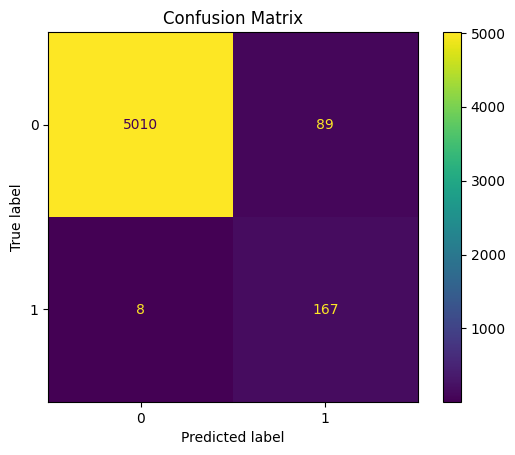

In [109]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(pred,y_test)
plt.figure(figsize=(14,6))
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()


In [110]:
from sklearn.metrics import roc_auc_score,roc_curve
prob=gcv.predict_proba(x_test_scale)[:,1]
roc=roc_auc_score(y_test,prob)
print(roc)

0.985286562126345


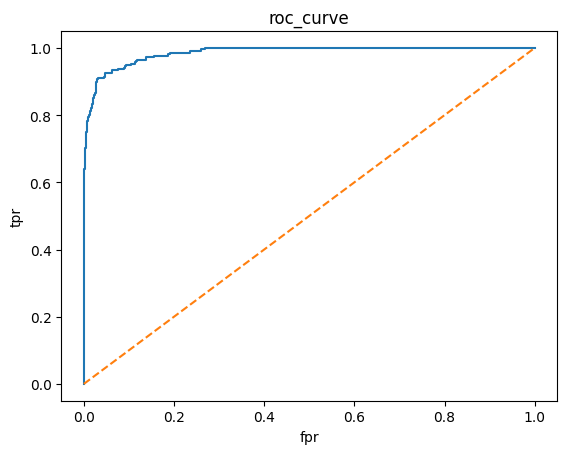

In [111]:
fpr,tpr,threshold=roc_curve(y_test,prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.title('roc_curve')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()